In [1]:
import math
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
from LBFGS import *

In [ ]:
class PureBendingBeam(keras.Model):
    def __init__(self, network_w, train_op, num_epoch, data_type):
        super().__init__()
        self.network_w = network_w
        self.optimizer = train_op
        self.num_epoch = num_epoch
        self.data_type = data_type
        self.print_epoch = 100
        self.network_w.build((None, 1))

    @tf.function
    def w(self, x):
        
        X1 = self.network_w(x)
        return X1 * x  # Manipulating the output of the neural network so that w = 0 at x = 0 (one of the BCs)

    @tf.function
    def call(self, X):
        wVal = self.w(X)
        return wVal

    def derivatives(self, x):
        # The correct way to get higher-order derivatives is to nest tapes. Calculating upto 4th derivative as needed for the PDE 
        with tf.GradientTape() as tape4:
            tape4.watch(x)
            with tf.GradientTape() as tape3:
                tape3.watch(x)
                with tf.GradientTape() as tape2:
                    tape2.watch(x)
                    with tf.GradientTape() as tape1:
                        tape1.watch(x)
                        W = self.w(x)
                    dw_dx = tape1.gradient(W, x)
                d2w_dx2 = tape2.gradient(dw_dx, x)
            d3w_dx3 = tape3.gradient(d2w_dx2, x)
        d4w_dx4 = tape4.gradient(d3w_dx3, x)
        
      
        return dw_dx, d2w_dx2, d3w_dx3, d4w_dx4

    @tf.function
    def loss_all(self, x):
        E = 2e11
        d = 0.03 # diameter
        I = math.pi * d**4 / 64
        P = 1e3

        dw_dx, d2w_dx2, d3w_dx3, d4w_dx4 = self.derivatives(x)
        
        dw_dx_s = dw_dx[0:1]
        d2w_dx2_e = d2w_dx2[-1:]
        d3w_dx3_e = d3w_dx3[-1:]

        # Physics loss (simplified form is more stable)
        loss_eq = tf.reduce_mean(tf.square(d4w_dx4))

        # Boundary loss with all three soft constraints
        loss_boundary_D = tf.reduce_mean(tf.square(dw_dx_s)) + \
                          tf.reduce_mean(tf.square(d2w_dx2_e)) + \
                          tf.reduce_mean(tf.square(E * I * d3w_dx3_e + P))
        
        return loss_eq, loss_boundary_D

    @tf.function
    def loss_grad(self, X_dom):
        # This function is now correctly included
        with tf.GradientTape() as tape:
            loss_eq, loss_boundary = self.loss_all(X_dom)
            # Use the correct data-driven weight
            losses = loss_eq + 1e-7 * loss_boundary
        grad = tape.gradient(losses, self.trainable_variables)
        return loss_eq, loss_boundary, losses, grad
    
    def train(self, X_dom):
        for epoch in range(self.num_epoch):
            with tf.GradientTape() as tape:
                loss_val1, loss_val2 = self.loss_all(X_dom)
                loss_val = loss_val1 + 1e-7 * loss_val2
                grads = tape.gradient(loss_val, self.trainable_variables)
            self.optimizer.apply_gradients(zip(grads, self.trainable_variables))

            if (epoch + 1) % self.print_epoch == 0:
                print(f"  PDE Loss: {loss_val1.numpy():.4e}, Boundary Loss: {loss_val2.numpy():.4e}")
                print("Epoch:", epoch + 1, "Loss:", loss_val.numpy())

    # def train(self, X_dom):
    #     for epoch in range(self.num_epoch):
    #         with tf.GradientTape() as tape:
    #             loss_val1, loss_val2 = self.loss_all(X_dom)
                
    #             # Use the correct data-driven weight
    #             loss_val = loss_val1 + 1e-7 * loss_val2
                
    #             grads = tape.gradient(loss_val, self.trainable_variables)
    #             grads = [tf.clip_by_value(g, -1.0, 1.0) for g in grads if g is not None]

    #         self.optimizer.apply_gradients(zip(grads, self.trainable_variables))

    #         if (epoch + 1) % self.print_epoch == 0:
    #             print(f"  PDE Loss: {loss_val1.numpy():.4e}, Boundary Loss: {loss_val2.numpy():.4e}")
    #             print(f"Epoch: {epoch + 1}, Total Loss: {loss_val.numpy():.4e}")

In [ ]:
Lx = 1.0
num_points = 101
x = np.linspace(0, Lx, num_points).reshape(-1, 1)

data_type = 'float64'
X_dom_tf = tf.convert_to_tensor(x, dtype=tf.float64)
tf.keras.backend.set_floatx(data_type)

# Define the neural network
network_w = keras.Sequential([
    keras.layers.Dense(20, activation='tanh', dtype=data_type),
    keras.layers.Dense(20, activation='tanh', dtype=data_type),
    keras.layers.Dense(20, activation='tanh', dtype=data_type),
    keras.layers.Dense(1, dtype=data_type)
])

# Define the optimizer and number of epochs
train_op = tf.keras.optimizers.Adam(learning_rate=1e-5)
num_epoch = 3000


# Create the model instance, passing all required arguments
pred_model = PureBendingBeam(network_w, train_op, num_epoch, data_type)
# ==================================================================

# Train the model
pred_model.train(X_dom_tf)

# (L-BFGS part can be run after this)
# l_bfgs_b = Opt_lbfgsb(pred_model, X_dom_tf)
# result = l_bfgs_b.fit()

  PDE Loss: 2.8714e-01, Boundary Loss: 5.0866e+05
Epoch: 100 Loss: 0.3380054137724218
  PDE Loss: 1.4840e-01, Boundary Loss: 5.4324e+05
Epoch: 200 Loss: 0.20272336785646478
  PDE Loss: 8.4049e-02, Boundary Loss: 4.1549e+05
Epoch: 300 Loss: 0.12559727433568063
  PDE Loss: 5.2090e-02, Boundary Loss: 2.8418e+05
Epoch: 400 Loss: 0.08050833984020248
  PDE Loss: 3.5156e-02, Boundary Loss: 1.8611e+05
Epoch: 500 Loss: 0.05376696678658897
  PDE Loss: 2.5273e-02, Boundary Loss: 1.1944e+05
Epoch: 600 Loss: 0.03721703883920874
  PDE Loss: 1.8831e-02, Boundary Loss: 7.6020e+04
Epoch: 700 Loss: 0.02643332137205891
  PDE Loss: 1.4297e-02, Boundary Loss: 4.8305e+04
Epoch: 800 Loss: 0.019127852600101265
  PDE Loss: 1.1007e-02, Boundary Loss: 3.0677e+04
Epoch: 900 Loss: 0.01407495849061468
  PDE Loss: 8.6127e-03, Boundary Loss: 1.9433e+04
Epoch: 1000 Loss: 0.01055598962454289
  PDE Loss: 6.8812e-03, Boundary Loss: 1.2247e+04
Epoch: 1100 Loss: 0.008105947638255059
  PDE Loss: 5.6356e-03, Boundary Loss: 7

In [11]:
l_bfgs_b = Opt_lbfgsb(pred_model, X_dom_tf)
result = l_bfgs_b.fit()

Optimizer: L-BFGS-B (Provided by Scipy package)
Initializing the framework ...
Iteration: 1, Loss = 1.3909e-03
Iteration: 2, Loss = 6.7864e+00
Iteration: 3, Loss = 1.3523e-03
Iteration: 4, Loss = 1.2872e-03
Iteration: 5, Loss = 1.0945e-03
Iteration: 6, Loss = 9.9743e-04
Iteration: 7, Loss = 8.9305e-04
Iteration: 8, Loss = 7.5938e-04
Iteration: 9, Loss = 6.6942e-04
Iteration: 10, Loss = 4.9884e-04
Iteration: 11, Loss = 3.5674e-04
Iteration: 12, Loss = 1.8331e-04
Iteration: 13, Loss = 1.4799e-04
Iteration: 14, Loss = 1.4371e-04
Iteration: 15, Loss = 1.4286e-04
Iteration: 16, Loss = 1.4238e-04
Iteration: 17, Loss = 1.4193e-04
Iteration: 18, Loss = 1.4050e-04
Iteration: 19, Loss = 1.3688e-04
Iteration: 20, Loss = 1.2795e-04
Iteration: 21, Loss = 1.0844e-04
Iteration: 22, Loss = 8.4415e-05
Iteration: 23, Loss = 5.6642e-05
Iteration: 24, Loss = 2.9116e-05
Iteration: 25, Loss = 2.1225e-05
Iteration: 26, Loss = 2.4296e-05
Iteration: 27, Loss = 1.8358e-05
Iteration: 28, Loss = 1.7138e-05
Iterat

In [12]:
Lx = 1.0
num_points = 101
x = np.linspace(0, Lx, num_points).reshape(-1, 1)

predicted_displacement = pred_model(x)
w_disp = predicted_displacement

In [15]:
P = 1e3
E = 2e11
d = 0.03
I = math.pi * d**4 / 64
w_anal = P/(6*E*I) * x*x * (3 * Lx - x)


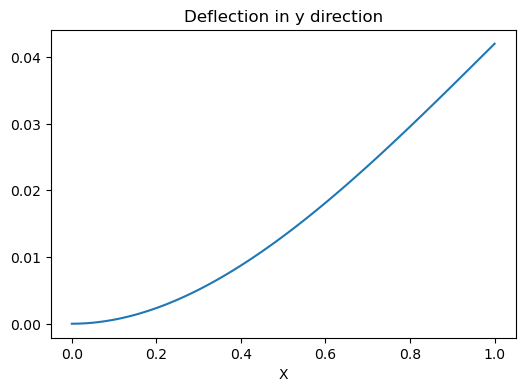

In [13]:
plt.figure(figsize=(6, 4))
plt.plot(x, w_disp.numpy(), label='Deflection')

#plt.ylim(0.5, 1.5)
plt.xlabel('X')
plt.title('Deflection in y direction')
plt.show()

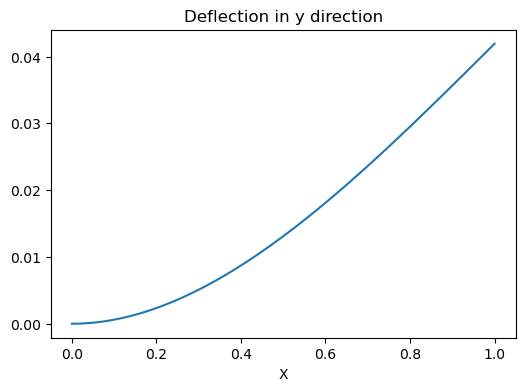

In [17]:
plt.figure(figsize=(6, 4))
plt.plot(x, w_anal, label='Deflection')

#plt.ylim(0.5, 1.5)
plt.xlabel('X')
plt.title('Deflection in y direction')
plt.show()

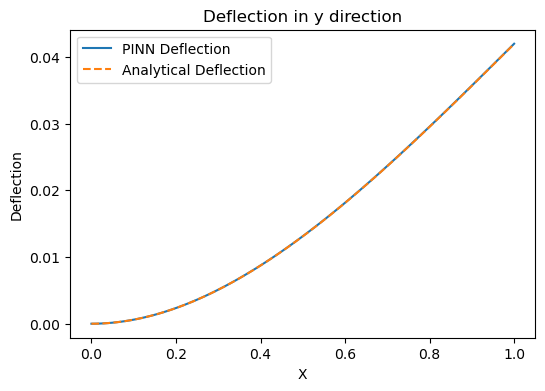

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(x, w_disp.numpy(), label='PINN Deflection')        # PINN prediction
plt.plot(x, w_anal, label='Analytical Deflection', linestyle='dashed')  # Analytical solution

plt.xlabel('X')
plt.ylabel('Deflection')
plt.title('Deflection in y direction')
plt.legend()
plt.show()
